# YOLO26 Baseline Benchmarks

Benchmark every baseline YOLO26 segmentation run on the held-out `ds-b-custom-sam3-v1/test` split using Ultralytics benchmark mode.

This notebook benchmarks `weights/best.pt` for each run, limits benchmark mode to PyTorch (`format="-"`), and writes summary outputs under `results/baseline_yolo26_twcc/benchmarks`.

In [8]:
from __future__ import annotations

import json
import os
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
from typing import Any

import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print


def resolve_project_paths() -> tuple[Path, Path, Path]:
    cwd = Path.cwd().resolve()
    if cwd.name == "rebar-segementation-yolo26" and (cwd / "train.py").is_file():
        rebar_dir = cwd
        model_training_dir = rebar_dir.parent
        return model_training_dir.parent, model_training_dir, rebar_dir

    for candidate in (cwd, *cwd.parents):
        rebar_dir = candidate / "model-training" / "rebar-segementation-yolo26"
        if (rebar_dir / "train.py").is_file():
            return candidate, candidate / "model-training", rebar_dir

    raise FileNotFoundError("Could not locate model-training/rebar-segementation-yolo26 from the current working directory.")


REPO_ROOT, MODEL_TRAINING_DIR, REBAR_DIR = resolve_project_paths()
RUNS_DIR = REBAR_DIR / "results" / "baseline_yolo26_twcc" / "runs" / "segment"
RESULTS_DIR = REBAR_DIR / "results" / "baseline_yolo26_twcc" / "benchmarks"
DATASET_DIR = MODEL_TRAINING_DIR / "datasets" / "ds-b-custom-sam3-v1"
SOURCE_DATA_YAML = DATASET_DIR / "data.yaml"
BENCHMARK_DATA_YAML = RESULTS_DIR / "ds_b_test_benchmark_data.yaml"

WEIGHT_NAME = "best.pt"
IMGSZ = 640
HALF = False
FORMAT = "-"  # Ultralytics export format argument for native PyTorch.


def resolve_device(requested: str = "auto") -> str:
    if requested != "auto":
        return requested

    try:
        import torch
    except ImportError:
        return "cpu"

    if torch.cuda.is_available():
        return "0"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = resolve_device("auto")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Runs dir: {RUNS_DIR}")
print(f"Dataset dir: {DATASET_DIR}")
print(f"Benchmark outputs: {RESULTS_DIR}")
print(f"Device: {DEVICE}")

Repo root: /Users/hungkaihsiao/Documents/rebar-works
Runs dir: /Users/hungkaihsiao/Documents/rebar-works/model-training/rebar-segementation-yolo26/results/baseline_yolo26_twcc/runs/segment
Dataset dir: /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1
Benchmark outputs: /Users/hungkaihsiao/Documents/rebar-works/model-training/rebar-segementation-yolo26/results/baseline_yolo26_twcc/benchmarks
Device: mps


## Validate the Held-Out Test Split

Ultralytics `benchmark()` validates against the dataset YAML's `val` entry. To guarantee the held-out test split is used, this notebook writes a benchmark-only YAML where `val` points to `test/images`.

In [9]:
IMAGE_EXTENSIONS = {".bmp", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"}


def iter_images(images_dir: Path) -> list[Path]:
    return sorted(
        path for path in images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def validate_yolo_split(dataset_dir: Path, split: str) -> dict[str, Any]:
    images_dir = dataset_dir / split / "images"
    labels_dir = dataset_dir / split / "labels"

    if not images_dir.is_dir():
        raise FileNotFoundError(f"Missing images directory: {images_dir}")
    if not labels_dir.is_dir():
        raise FileNotFoundError(f"Missing labels directory: {labels_dir}")

    images = iter_images(images_dir)
    image_stems = {path.stem for path in images}
    label_stems = {path.stem for path in labels_dir.glob("*.txt")}
    missing_labels = sorted(image_stems - label_stems)
    orphan_labels = sorted(label_stems - image_stems)

    if missing_labels:
        raise ValueError(f"{split} has images without labels: {missing_labels[:5]}")
    if orphan_labels:
        raise ValueError(f"{split} has labels without images: {orphan_labels[:5]}")

    return {
        "split": split,
        "images": len(images),
        "labels": len(label_stems),
        "images_dir": str(images_dir),
        "labels_dir": str(labels_dir),
    }


test_summary = validate_yolo_split(DATASET_DIR, "test")
assert SOURCE_DATA_YAML.is_file(), f"Missing source dataset YAML: {SOURCE_DATA_YAML}"
display(pd.DataFrame([test_summary]))

,split,images,labels,images_dir,labels_dir
0,test,15,15,/Users/hungkaihsiao/Documents/rebar-works/mode...,/Users/hungkaihsiao/Documents/rebar-works/mode...


In [10]:
def write_benchmark_data_yaml(path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    yaml_text = "\n".join(
        [
            f"path: {DATASET_DIR.as_posix()}",
            "train: train/images",
            "val: test/images",
            "test: test/images",
            "",
            "nc: 1",
            "names:",
            "  0: rebar",
            "",
        ]
    )
    path.write_text(yaml_text, encoding="utf-8")


write_benchmark_data_yaml(BENCHMARK_DATA_YAML)
print(BENCHMARK_DATA_YAML.read_text(encoding="utf-8"))

path: /Users/hungkaihsiao/Documents/rebar-works/model-training/datasets/ds-b-custom-sam3-v1
train: train/images
val: test/images
test: test/images

nc: 1
names:
  0: rebar



## Discover Baseline Checkpoints

In [11]:
def discover_checkpoints(runs_dir: Path, weight_name: str) -> pd.DataFrame:
    if not runs_dir.is_dir():
        raise FileNotFoundError(f"Missing runs directory: {runs_dir}")

    rows = []
    missing = []
    for run_dir in sorted(path for path in runs_dir.iterdir() if path.is_dir()):
        checkpoint = run_dir / "weights" / weight_name
        if checkpoint.is_file():
            rows.append(
                {
                    "run_name": run_dir.name,
                    "checkpoint": str(checkpoint),
                    "checkpoint_size_mb": round(checkpoint.stat().st_size / 1_000_000, 2),
                }
            )
        else:
            missing.append(str(checkpoint))

    if missing:
        raise FileNotFoundError("Some runs are missing the requested checkpoint:\n" + "\n".join(missing))
    if not rows:
        raise FileNotFoundError(f"No {weight_name} checkpoints found in {runs_dir}")

    return pd.DataFrame(rows)


checkpoints = discover_checkpoints(RUNS_DIR, WEIGHT_NAME)
print(f"Found {len(checkpoints)} checkpoints.")
display(checkpoints)

Found 14 checkpoints.


,run_name,checkpoint,checkpoint_size_mb
0,yolo26x-baseline-a-aug0-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72
1,yolo26x-baseline-a-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72
2,yolo26x-baseline-a-b-aug0-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72
3,yolo26x-baseline-a-b-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72
4,yolo26x-baseline-a-b-c-aug0-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72
5,yolo26x-baseline-a-b-c-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72
6,yolo26x-baseline-a-c-aug0-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72
7,yolo26x-baseline-a-c-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72
8,yolo26x-baseline-b-aug0-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72
9,yolo26x-baseline-b-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,141.72


## Run PyTorch Benchmarks

The benchmark loop writes one subdirectory per model so each model keeps its own `benchmarks.log`. The summary CSV and JSON files are written after every row, so partial results are preserved if a long run is interrupted.

In [12]:
@contextmanager
def pushd(path: Path):
    old_cwd = Path.cwd()
    path.mkdir(parents=True, exist_ok=True)
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(old_cwd)


def dataframe_from_benchmark(result: Any) -> pd.DataFrame:
    if hasattr(result, "to_dicts"):
        return pd.DataFrame(result.to_dicts())
    if hasattr(result, "to_pandas"):
        return result.to_pandas()
    if isinstance(result, pd.DataFrame):
        return result.copy()
    return pd.DataFrame(result)


def clean_value(value: Any) -> Any:
    if value is None:
        return None
    if isinstance(value, str):
        stripped = value.strip()
        if stripped in {"", "-", "None", "nan"}:
            return None
        try:
            return float(stripped)
        except ValueError:
            return stripped
    return value


def pick_column(columns: list[str], fragments: tuple[str, ...]) -> str | None:
    lowered = {column: column.lower() for column in columns}
    for column, lower in lowered.items():
        if all(fragment.lower() in lower for fragment in fragments):
            return column
    return None


def summarize_benchmark_frame(frame: pd.DataFrame) -> dict[str, Any]:
    if frame.empty:
        return {}

    columns = [str(column) for column in frame.columns]
    frame = frame.copy()
    frame.columns = columns

    format_col = pick_column(columns, ("format",))
    status_col = pick_column(columns, ("status",))
    speed_col = pick_column(columns, ("inference", "time"))
    fps_col = pick_column(columns, ("fps",))
    metric_col = next((column for column in columns if "map50-95" in column.lower()), None)
    size_col = pick_column(columns, ("size", "mb"))

    row = frame.iloc[0].to_dict()
    return {
        "benchmark_format": row.get(format_col) if format_col else None,
        "benchmark_status": row.get(status_col) if status_col else None,
        "map50_95": clean_value(row.get(metric_col)) if metric_col else None,
        "metric_column": metric_col,
        "inference_ms_per_image": clean_value(row.get(speed_col)) if speed_col else None,
        "fps": clean_value(row.get(fps_col)) if fps_col else None,
        "benchmark_size_mb": clean_value(row.get(size_col)) if size_col else None,
        "raw_columns": json.dumps(columns),
    }


def run_one_benchmark(run_name: str, checkpoint: str) -> tuple[dict[str, Any], pd.DataFrame]:
    from ultralytics.utils.benchmarks import benchmark

    model_output_dir = RESULTS_DIR / run_name
    started_at = datetime.now().isoformat(timespec="seconds")

    with pushd(model_output_dir):
        result = benchmark(
            model=checkpoint,
            data=str(BENCHMARK_DATA_YAML),
            imgsz=IMGSZ,
            half=HALF,
            device=DEVICE,
            verbose=False,
            format=FORMAT,
        )

    frame = dataframe_from_benchmark(result)
    summary = summarize_benchmark_frame(frame)
    summary.update(
        {
            "run_name": run_name,
            "checkpoint": checkpoint,
            "weight_name": WEIGHT_NAME,
            "data_yaml": str(BENCHMARK_DATA_YAML),
            "source_data_yaml": str(SOURCE_DATA_YAML),
            "dataset_split": "test via benchmark YAML val=test/images",
            "imgsz": IMGSZ,
            "half": HALF,
            "device": DEVICE,
            "format_arg": FORMAT,
            "output_dir": str(model_output_dir),
            "started_at": started_at,
            "finished_at": datetime.now().isoformat(timespec="seconds"),
            "error": None,
        }
    )
    return summary, frame


In [14]:
SUMMARY_CSV = RESULTS_DIR / "baseline_yolo26_best_pt_pytorch_ds_b_test.csv"
SUMMARY_JSON = RESULTS_DIR / "baseline_yolo26_best_pt_pytorch_ds_b_test.json"
RAW_JSON = RESULTS_DIR / "baseline_yolo26_best_pt_pytorch_ds_b_test_raw.json"

In [ ]:
summary_rows: list[dict[str, Any]] = []
raw_rows: list[dict[str, Any]] = []

for index, item in checkpoints.iterrows():
    run_name = item["run_name"]
    checkpoint = item["checkpoint"]
    print(f"[{index + 1}/{len(checkpoints)}] Benchmarking {run_name}")

    try:
        summary, raw_frame = run_one_benchmark(run_name, checkpoint)
    except Exception as exc:
        summary = {
            "run_name": run_name,
            "checkpoint": checkpoint,
            "weight_name": WEIGHT_NAME,
            "data_yaml": str(BENCHMARK_DATA_YAML),
            "source_data_yaml": str(SOURCE_DATA_YAML),
            "dataset_split": "test via benchmark YAML val=test/images",
            "imgsz": IMGSZ,
            "half": HALF,
            "device": DEVICE,
            "format_arg": FORMAT,
            "output_dir": str(RESULTS_DIR / run_name),
            "benchmark_format": None,
            "benchmark_status": "failed",
            "map50_95": None,
            "metric_column": None,
            "inference_ms_per_image": None,
            "fps": None,
            "benchmark_size_mb": None,
            "raw_columns": None,
            "started_at": None,
            "finished_at": datetime.now().isoformat(timespec="seconds"),
            "error": repr(exc),
        }
        raw_frame = pd.DataFrame()
        print(f"  failed: {exc!r}")

    summary_rows.append(summary)
    if not raw_frame.empty:
        raw = raw_frame.copy()
        raw.insert(0, "run_name", run_name)
        raw_rows.extend(raw.to_dict(orient="records"))

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(SUMMARY_CSV, index=False)
    SUMMARY_JSON.write_text(json.dumps(summary_rows, indent=2), encoding="utf-8")
    RAW_JSON.write_text(json.dumps(raw_rows, indent=2, default=str), encoding="utf-8")

summary_df = pd.DataFrame(summary_rows).sort_values(
    by=["map50_95", "inference_ms_per_image"],
    ascending=[False, True],
    na_position="last",
)
summary_df.to_csv(SUMMARY_CSV, index=False)
SUMMARY_JSON.write_text(json.dumps(summary_df.to_dict(orient="records"), indent=2), encoding="utf-8")

print(f"Wrote summary CSV: {SUMMARY_CSV}")
print(f"Wrote summary JSON: {SUMMARY_JSON}")
print(f"Wrote raw JSON: {RAW_JSON}")
display(summary_df)

Setup complete ✅ (8 CPUs, 8.0 GB RAM, 136.9/228.3 GB disk)

Benchmarks complete for /Users/hungkaihsiao/Documents/rebar-works/model-training/rebar-segementation-yolo26/results/baseline_yolo26_twcc/runs/segment/yolo26x-baseline-c-aug1-v1/weights/best.pt on /Users/hungkaihsiao/Documents/rebar-works/model-training/rebar-segementation-yolo26/results/baseline_yolo26_twcc/benchmarks/ds_b_test_benchmark_data.yaml at imgsz=640 (8.78s)
Benchmarks legend:  - ✅ Success  - ❎ Export passed but validation failed  - ❌️ Export failed
+------------------------------------------------------------------------------------------+
|     Format    Status❔   Size (MB)   metrics/mAP50-95(M)   Inference time (ms/im)   FPS  |
+==========================================================================================+
| 1   PyTorch   ✅         135.2       0.025                 261.83                   3.82 |
+------------------------------------------------------------------------------------------+

Wrote summar

,benchmark_format,benchmark_status,map50_95,metric_column,inference_ms_per_image,fps,benchmark_size_mb,raw_columns,run_name,checkpoint,...,source_data_yaml,dataset_split,imgsz,half,device,format_arg,output_dir,started_at,finished_at,error
3,PyTorch,✅,0.0952,metrics/mAP50-95(M),245.14,4.08,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-a-b-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,...,/Users/hungkaihsiao/Documents/rebar-works/mode...,test via benchmark YAML val=test/images,640,False,mps,-,/Users/hungkaihsiao/Documents/rebar-works/mode...,2026-05-26T12:50:24,2026-05-26T12:50:31,None
5,PyTorch,✅,0.0914,metrics/mAP50-95(M),238.24,4.20,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-a-b-c-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,...,/Users/hungkaihsiao/Documents/rebar-works/mode...,test via benchmark YAML val=test/images,640,False,mps,-,/Users/hungkaihsiao/Documents/rebar-works/mode...,2026-05-26T12:50:40,2026-05-26T12:50:48,None
9,PyTorch,✅,0.0689,metrics/mAP50-95(M),245.59,4.07,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-b-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,...,/Users/hungkaihsiao/Documents/rebar-works/mode...,test via benchmark YAML val=test/images,640,False,mps,-,/Users/hungkaihsiao/Documents/rebar-works/mode...,2026-05-26T12:51:11,2026-05-26T12:51:19,None
11,PyTorch,✅,0.0609,metrics/mAP50-95(M),256.94,3.89,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-b-c-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,...,/Users/hungkaihsiao/Documents/rebar-works/mode...,test via benchmark YAML val=test/images,640,False,mps,-,/Users/hungkaihsiao/Documents/rebar-works/mode...,2026-05-26T12:51:27,2026-05-26T12:51:35,None
4,PyTorch,✅,0.0606,metrics/mAP50-95(M),242.73,4.12,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-a-b-c-aug0-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,...,/Users/hungkaihsiao/Documents/rebar-works/mode...,test via benchmark YAML val=test/images,640,False,mps,-,/Users/hungkaihsiao/Documents/rebar-works/mode...,2026-05-26T12:50:31,2026-05-26T12:50:40,None
2,PyTorch,✅,0.0584,metrics/mAP50-95(M),242.91,4.12,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-a-b-aug0-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,...,/Users/hungkaihsiao/Documents/rebar-works/mode...,test via benchmark YAML val=test/images,640,False,mps,-,/Users/hungkaihsiao/Documents/rebar-works/mode...,2026-05-26T12:50:15,2026-05-26T12:50:24,None
8,PyTorch,✅,0.0520,metrics/mAP50-95(M),243.25,4.11,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-b-aug0-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,...,/Users/hungkaihsiao/Documents/rebar-works/mode...,test via benchmark YAML val=test/images,640,False,mps,-,/Users/hungkaihsiao/Documents/rebar-works/mode...,2026-05-26T12:51:03,2026-05-26T12:51:11,None
1,PyTorch,✅,0.0431,metrics/mAP50-95(M),239.37,4.18,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-a-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,...,/Users/hungkaihsiao/Documents/rebar-works/mode...,test via benchmark YAML val=test/images,640,False,mps,-,/Users/hungkaihsiao/Documents/rebar-works/mode...,2026-05-26T12:50:07,2026-05-26T12:50:15,None
7,PyTorch,✅,0.0425,metrics/mAP50-95(M),239.16,4.18,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-a-c-aug1-v1,/Users/hungkaihsiao/Documents/rebar-works/mode...,...,/Users/hungkaihsiao/Documents/rebar-works/mode...,test via benchmark YAML val=test/images,640,False,mps,-,/Users/hungkaihsiao/Documents/rebar-works/mode...,2026-05-26T12:50:56,2026-05-26T12:51:03,None
10,PyTorch,✅,0.0405,metrics/mAP50-95(M),238.59,4.19,135.2,"["" "", ""Format"", ""Status\u2754"", ""Size (MB)"", ""...",yolo26x-baseline-b-c-aug0

## Model Performance by mAP50-95

Display the benchmarked models ranked by segmentation `map50_95`. This cell uses `baseline_yolo26_best_pt_pytorch_ds_b_test.csv` as the source of truth for the metrics.

,run_name,map50_95,inference_ms_per_image,benchmark_status
rank,,,,
1,yolo26x-baseline-a-b-aug1-v1,0.0952,245.14,✅
2,yolo26x-baseline-a-b-c-aug1-v1,0.0914,238.24,✅
3,yolo26x-baseline-b-aug1-v1,0.0689,245.59,✅
4,yolo26x-baseline-b-c-aug1-v1,0.0609,256.94,✅
5,yolo26x-baseline-a-b-c-aug0-v1,0.0606,242.73,✅
6,yolo26x-baseline-a-b-aug0-v1,0.0584,242.91,✅
7,yolo26x-baseline-b-aug0-v1,0.0520,243.25,✅
8,yolo26x-baseline-a-aug1-v1,0.0431,239.37,✅
9,yolo26x-baseline-a-c-aug1-v1,0.0425,239.16,✅


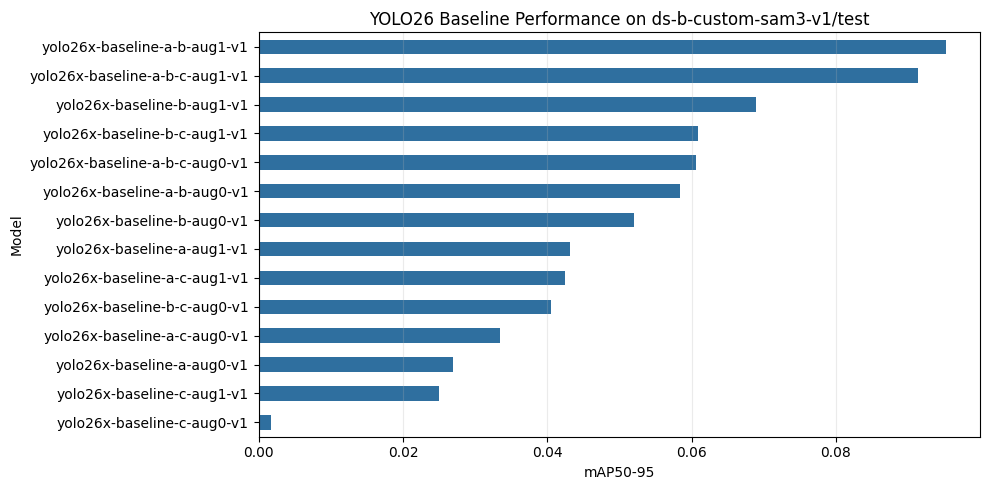

In [15]:
def load_performance_summary() -> pd.DataFrame:
    if not SUMMARY_CSV.is_file():
        raise FileNotFoundError(f"Benchmark summary not found: {SUMMARY_CSV}. Run the benchmark cell first.")

    return pd.read_csv(SUMMARY_CSV)


performance_df = load_performance_summary()
required_columns = {"run_name", "map50_95"}
missing_columns = required_columns - set(performance_df.columns)
if missing_columns:
    raise ValueError(f"Benchmark summary is missing required column(s): {sorted(missing_columns)}")

performance_df = performance_df.copy()
performance_df["map50_95"] = pd.to_numeric(performance_df["map50_95"], errors="coerce")
if "inference_ms_per_image" in performance_df.columns:
    performance_df["inference_ms_per_image"] = pd.to_numeric(performance_df["inference_ms_per_image"], errors="coerce")
else:
    performance_df["inference_ms_per_image"] = pd.NA
if "benchmark_status" not in performance_df.columns:
    performance_df["benchmark_status"] = pd.NA

performance_df = performance_df.dropna(subset=["map50_95"]).sort_values("map50_95", ascending=False)
if performance_df.empty:
    raise ValueError("No valid map50_95 values found. Run the benchmark cell first and check failed rows.")

ranking_columns = ["run_name", "map50_95", "inference_ms_per_image", "benchmark_status"]
ranking_df = performance_df[ranking_columns].reset_index(drop=True)
ranking_df.index = ranking_df.index + 1
ranking_df.index.name = "rank"

display(
    ranking_df.style.format(
        {
            "map50_95": "{:.4f}",
            "inference_ms_per_image": "{:.2f}",
        },
        na_rep="-",
    )
)

ax = ranking_df.sort_values("map50_95", ascending=True).plot.barh(
    x="run_name",
    y="map50_95",
    legend=False,
    figsize=(10, max(5, 0.35 * len(ranking_df))),
    color="#2f6f9f",
)
ax.set_title("YOLO26 Baseline Performance on ds-b-custom-sam3-v1/test")
ax.set_xlabel("mAP50-95")
ax.set_ylabel("Model")
ax.grid(axis="x", alpha=0.25)
ax.figure.tight_layout()
